### Process WVS wave-7 data (summary)

#### Data preparation
- Read timeseries data
- Select wave7 and a subset of columns 
    - individual ID
    - country code
    - demographic items
    - Inglehart-welzel dimensions
    - items with responses >= 50% (sort items by alphabetic order)
        
- Country abbreviation to country
- Rename demographic columns and group the values
- Check item correlations 
    - not removing any items (highest correlation is 0.7)

#### Identify and revise mismatched items (survey VS timeseries)
- 5 mismatched item response code from timeseries and wvs7 survey
- Code revision only for positive values

#### Encode the range of the survey questions
- prepare for data standardization in the next step

#### Make item response sentiment/intensity directions consistent 
- weak/negative → strong/positive
- manually identify items need to reverse

#### Standard data processing
- Drop E003 and E004
- Fill in invalid/negative/missing values with country average of positive values
- MinmaxScalar using the full range of item responses
- Calculate country mean
- Robustness check: all scaled items should be in the range of 0 and 1

#### Calculate country average of human representations

In [1]:
import json
import pandas as pd 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### Data Preparation

In [ ]:
# get the selected survey items (takes 15 seconds to run)
df_wvs_ts = pd.read_csv("./data/WVS_Time_Series_1981-2022_csv_v5_0.csv")
df_wv7_ts = df_wvs_ts[df_wvs_ts['S002VS'] == 7]
df_wv7_ts.shape

(97220, 1046)

In [ ]:
with open('./data/country_abr.json','r') as f:
    abr_map = json.load(f)

df_wv7_ts["Country"] = df_wv7_ts['COUNTRY_ALPHA'].map(abr_map)

In [5]:
# summarize selected items
demo_columns = ['X001', 'X003', 'X025A_01', 'X028', 'X045'] # gender, age, education, employment, social_class
IGW_columns = ['survself', 'tradrat5', 'TradAgg', 'SurvSAgg']
# the selected items are from 1.1_WVS_exploration.ipynb
selected_items = sorted(['H008_07', 'E004', 'H008_08', 'E277', 'E003', 'E034', 'A165', 'B008', 'H008_01', 'G058', 'D078', 'E117B', 'E260B', 'E069_12', 'E069_05', 'E069_54', 'E259B', 'E018', 'E268', 'H008_04', 'A002', 'A004', 'C039', 'F028', 'F114D', 'F117', 'F114C', 'E287', 'F123', 'G007_36_B', 'G063', 'A009', 'D026_05', 'E025', 'E289', 'E039', 'F114B', 'A003', 'D057', 'A005', 'E261B', 'E069_41', 'D060', 'F120', 'E035', 'E069_14', 'E069_40', 'E023', 'H008_02', 'G007_35_B', 'E117', 'E114', 'C038', 'F121', 'E069_13', 'C006', 'F144_02', 'C041', 'E069_15', 'E235', 'E069_01', 'G062', 'E015', 'E115', 'D061', 'G007_18_B', 'E028', 'D059', 'F116', 'E027', 'E069_08', 'E248B', 'E069_10', 'H008_09', 'A008', 'F114A', 'E227', 'E224', 'E016', 'H001', 'E040', 'E225', 'F122', 'E036', 'E233A', 'H006_01', 'D001_B', 'F028B', 'E233', 'E262B', 'F206', 'E124', 'D066_01', 'E258B', 'E236', 'H008_03', 'E226', 'A006', 'H006_02', 'E069_07', 'F202', 'G052', 'E286', 'E229', 'A001', 'G007_34_B', 'E037', 'A170', 'C002_01', 'C001_01', 'E254B', 'E069_04', 'D054', 'E233B', 'E026', 'D026_03', 'A173', 'A062', 'G007_33_B'])
columns = ['Country'] + IGW_columns + selected_items + demo_columns
print(len(selected_items), len(columns))

119 129


In [6]:
# Y020: RESEMAVAL.- Welzel emancipative values
# Y010: SACSECVAL.- Welzel Overall Secular Values
'Y010' in df_wv7_ts.columns, 'Y020' in df_wv7_ts.columns

(True, True)

In [7]:
df_wv7_ts.head()

,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,S004,S006,...,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg,Country
3002,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070001,...,0.111111,0.444444,0.00,0.0,0.000,NaN,NaN,NaN,NaN,Andorra
3003,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070002,...,0.888889,0.888889,1.00,0.0,0.500,2.351776,-0.409820,-0.759811,4.294714,Andorra
3004,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070003,...,0.444444,0.555556,0.33,0.5,0.415,0.745465,1.080443,1.639513,1.387292,Andorra
3005,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070004,...,0.333333,0.888889,0.33,0.5,0.415,NaN,NaN,NaN,NaN,Andorra
3006,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070005,...,0.444444,0.666667,0.00,0.5,0.250,NaN,NaN,NaN,NaN,Andorra


In [8]:
df_wv7 = df_wv7_ts[columns].copy()
df_wv7.rename(columns={'X001':'gender', 'X003':'age', 'X025A_01':'education', 'X028':'employment', 'X045':'social_class'}, inplace=True)

In [ ]:
def gender_group(gender):
    if gender<0:
        return ""
    elif gender==1:
        return 'male'
    elif gender==2:
        return 'female'

def age_group(age):
    if age <=0:
        return ""
    elif age < 25:
        return "youth"
    elif age <= 60:
        return "middle"
    else:
        return "old"

def education_group(level):
    if level <=0:
        return ""
    elif level in [6,7,8]:
        return "university"
    elif level in [1,2,3,4,5]:
        return "non_university"

def employment_group(status):
    if status <=0:
        return ""
    elif status == 1:
        return "full_time"
    elif status in [2,3,4,5,6,7,8]:
        return "non_full_time"

def social_group(sclass):
    if sclass <=0:
        return ""
    elif sclass == 1:
        return "upper"
    elif sclass in [2,3,4]:
        return "middle"
    elif sclass == 5:
        return "lower"

In [9]:
df_wv7['gender'] = df_wv7['gender'].apply(gender_group)
df_wv7['age'] = df_wv7['age'].apply(age_group)
df_wv7['education'] = df_wv7['education'].apply(education_group)
df_wv7['employment'] = df_wv7['employment'].apply(employment_group)
df_wv7['social_class'] = df_wv7['social_class'].apply(social_group)

In [10]:
df_wv7.head()

,Country,survself,tradrat5,TradAgg,SurvSAgg,A001,A002,A003,A004,A005,...,H008_03,H008_04,H008_07,H008_08,H008_09,gender,age,education,employment,social_class
3002,Andorra,NaN,NaN,NaN,NaN,1,1,1,3,1,...,4,4,1,2,4,female,middle,non_university,full_time,middle
3003,Andorra,2.351776,-0.409820,-0.759811,4.294714,1,1,1,4,1,...,4,4,2,2,4,male,middle,non_university,full_time,middle
3004,Andorra,0.745465,1.080443,1.639513,1.387292,1,2,2,2,3,...,4,3,1,1,4,male,middle,non_university,full_time,middle
3005,Andorra,NaN,NaN,NaN,NaN,1,1,1,4,2,...,4,4,1,1,4,female,old,non_university,full_time,middle
3006,Andorra,NaN,NaN,NaN,NaN,1,1,1,3,1,...,4,4,1,2,4,male,middle,non_university,full_time,middle


For the 119 selected_items, check item correlations

In [11]:
df_wv7[selected_items]

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
3002,1,1,1,3,1,4,1,3,2,2,...,1,2,2,4,4,4,4,1,2,4
3003,1,1,1,4,1,4,1,1,2,2,...,1,2,2,4,4,4,4,2,2,4
3004,1,2,2,2,3,3,2,1,2,2,...,1,3,4,4,4,4,3,1,1,4
3005,1,1,1,4,2,4,2,2,-2,2,...,2,2,2,4,4,4,4,1,1,4
3006,1,1,1,3,1,3,2,2,2,2,...,2,2,2,4,4,4,4,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443483,1,3,1,1,1,2,2,1,3,2,...,1,2,2,3,3,2,1,2,2,3
443484,1,1,2,1,1,1,2,1,2,2,...,4,1,1,4,1,2,2,1,2,4
443485,1,3,2,2,2,2,3,3,3,2,...,2,1,1,2,2,2,2,1,2,4
443486,1,2,2,1,1,1,4,1,2,2,...,1,1,1,1,3,1,1,1,2,3


In [12]:
# pairwise pearson correlations between columns
corr_matrix = df_wv7[selected_items].corr(method="pearson")
# Keep only the upper triangle, excluding the diagonal
upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool),k=1)

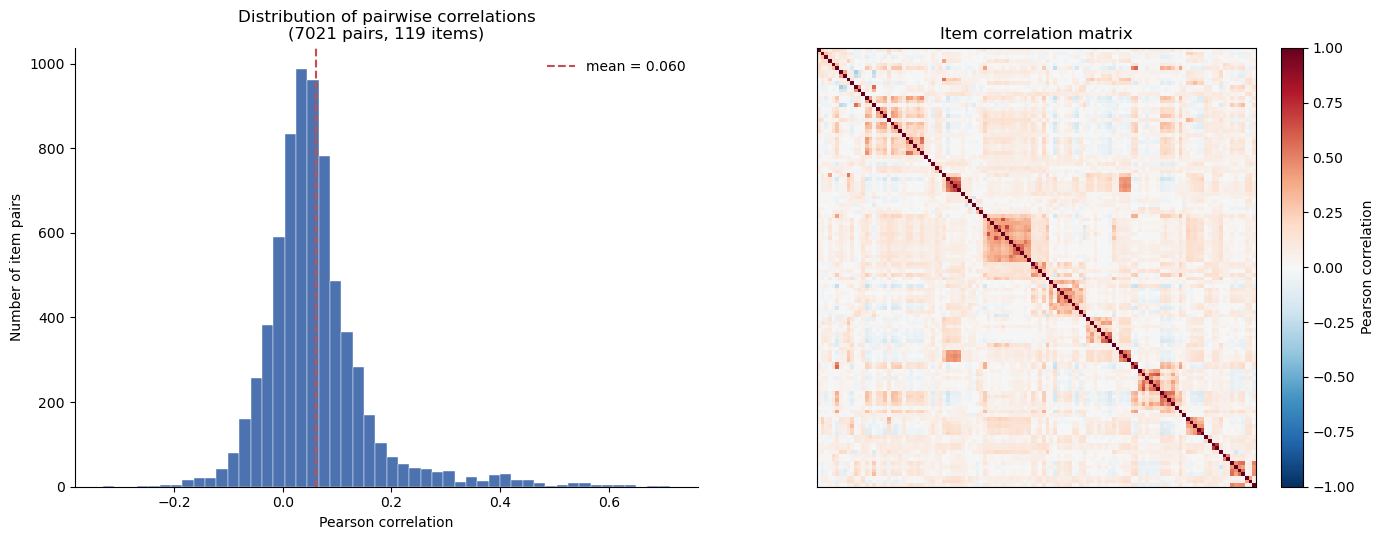

count    7021.000000
mean        0.060254
std         0.096600
min        -0.330481
25%         0.007622
50%         0.047222
75%         0.090647
max         0.712281
dtype: float64

In [13]:
# Distribution of pairwise item correlations (upper triangle, excluding diagonal)
corr_values = corr_matrix.where(upper_mask).stack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Histogram of correlation coefficients
ax = axes[0]
ax.hist(corr_values, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.axvline(corr_values.mean(), color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"mean = {corr_values.mean():.3f}")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("Number of item pairs")
ax.set_title(f"Distribution of pairwise correlations\n({len(corr_values)} pairs, {len(selected_items)} items)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Heatmap of the full correlation matrix
ax = axes[1]
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Item correlation matrix")
ax.set_xticks([])
ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")

plt.tight_layout()
plt.show()

corr_values.describe()

In [14]:
# Item pairs with correlation > 0.5 (upper triangle, so each pair appears once)
threshold = 0.5
high_corr_pairs = (
    corr_matrix.where(upper_mask)
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "item_1", "level_1": "item_2"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["correlation"] > threshold]
high_corr_pairs = high_corr_pairs.sort_values("correlation", ascending=False).reset_index(drop=True)

print(f"{len(high_corr_pairs)} item pairs with correlation > {threshold}")
high_corr_pairs

41 item pairs with correlation > 0.5


,item_1,item_2,correlation
0,G062,G063,0.712281
1,G007_35_B,G007_36_B,0.708831
2,E027,E028,0.682506
3,E069_07,E069_12,0.673055
4,E069_04,E069_10,0.645691
5,F114B,F117,0.640841
6,F028,F028B,0.634844
7,E026,E027,0.634284
8,E026,E028,0.619912
9,E261B,E262B,0.616320


Conclusion:
- most correlations below 0.7, so keep all selected items for now
- for future exploration, could consider removing those > 0.5

### Identify and revise mismatch items
- timeseries data and wave-7 survey data have different item response code
- revise the timeseries data to make it consistent with survey data

In [ ]:
# load the item map from variable names to wave questions
df_var_map = pd.read_excel('./data/F00003844-WVS_Time_Series_List_of_Variables_and_equivalences_1981_2022_v3_1.xlsx')

df_var_map.head()

,Unnamed: 0,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
0,NaN,A001,Important in life: Family,Q1,V4,V4,V4,V4,V5,NaN
1,NaN,A002,Important in life: Friends,Q2,V5,V5,V5,V5,V6,NaN
2,NaN,A003,Important in life: Leisure time,Q3,V6,V6,V6,V6,V7,NaN
3,NaN,A004,Important in life: Politics,Q4,V7,V7,V7,V7,V8,NaN
4,NaN,A005,Important in life: Work,Q5,V8,V8,V8,V8,V4,NaN


In [ ]:
# load the wave 7 data from the separate file 
df_wv7_file = pd.read_csv('./data/WVS_Cross-National_Wave_7_csv_v6_0.csv')

# map columns of questions to be consistent with the timeseries Variable names (e.g. A001)
wvs7_to_variable = df_var_map.dropna(subset=['WVS7']).set_index('WVS7')['Variable'].to_dict()
df_wv7_file = df_wv7_file.rename(columns=wvs7_to_variable)

df_wv7_file.shape

(97220, 613)

In [19]:
# among all the 119 selected items, identify mismatch in their response distribution
# not explore other shared columns: demographic, etc
mismatch_items = []
for item in selected_items:
    if not df_wv7[item].value_counts().equals(df_wv7_file[item].value_counts()):
        mismatch_items.append(item)

print(mismatch_items)

['A165', 'E018', 'E025', 'E037', 'F028']


In [15]:
item = 'A165'

display(df_wv7[item].value_counts())
display(df_wv7_file[item].value_counts())

# do not need further revision

A165
 2    72616
 1    23267
-1      737
-2      600
Name: count, dtype: int64

A165
 2    72616
 1    23267
-1      737
-2      310
-5      290
Name: count, dtype: int64

In [20]:
item = 'E018'

display(df_wv7[item].value_counts())
display(df_wv7_file[item].value_counts())

# do not need further revision

E018
 1    55017
 2    24365
 3    15114
-1     1972
-2      752
Name: count, dtype: int64

E018
 1    55017
 2    24365
 3    15114
-1     1972
-2      522
-5      230
Name: count, dtype: int64

In [21]:
item = 'E025'

display(df_wv7[item].value_counts())
display(df_wv7_file[item].value_counts())

# do not need further revision

E025
 3    41087
 2    28727
 1    24216
-1     2241
-2      949
Name: count, dtype: int64

E025
 3    41087
 2    28727
 1    24216
-1     2241
-2      599
-5      350
Name: count, dtype: int64

In [22]:
item = 'E037'

display(df_wv7[item].value_counts())
display(df_wv7_file[item].value_counts())

# need further revision: revise wv7_ts response to: E037 = 11 - E037

E037
 10    19246
 6     15207
 1     11235
 3      8178
 5      8094
 4      8012
 8      7838
 7      7381
 9      6498
 2      4353
-1       717
-2       292
-5       169
Name: count, dtype: int64

E037
 1     19246
 5     15207
 10    11235
 8      8178
 6      8094
 7      8012
 3      7838
 4      7381
 2      6498
 9      4353
-1       717
-2       292
-5       169
Name: count, dtype: int64

In [23]:
item = 'F028'

display(df_wv7[item].value_counts())
display(df_wv7_file[item].value_counts())

# if (F028 > 5), F028 = F028 - 1
# else: F028 keep as it is

F028
 8    24468
 2    17350
 4    15060
 1    12825
 7    11774
 3     9627
 6     4904
-2      512
-1      374
-5      326
Name: count, dtype: int64

F028
 7    24468
 2    17350
 4    15060
 1    12825
 6    11774
 3     9627
 5     4904
-2      512
-1      374
-5      326
Name: count, dtype: int64

Make item response consistent with wave-7 survey design

In [24]:
# E037 = 11 - E037
# if (F028 > 5), F028 = F028 - 1; else: F028 keep as it is
df_wv7['E037'] = df_wv7['E037'].where(df_wv7['E037'] < 0, 11- df_wv7['E037'])
df_wv7['F028'] = df_wv7['F028'].where(df_wv7['F028'] <= 5, df_wv7['F028'] - 1)


In [25]:
df_wv7[['E037', 'F028']]

,E037,F028
3002,2,7
3003,2,7
3004,5,7
3005,5,7
3006,7,7
...,...,...
443483,5,2
443484,1,1
443485,1,3
443486,1,2


In [26]:
df_wv7[['E037']].value_counts()

E037
 1      19246
 5      15207
 10     11235
 8       8178
 6       8094
 7       8012
 3       7838
 4       7381
 2       6498
 9       4353
-1        717
-2        292
-5        169
Name: count, dtype: int64

In [27]:
df_wv7[['E028']].value_counts()

E028
 3      58174
 2      27318
 1       8090
-1       2457
-2        708
-5        473
Name: count, dtype: int64

### Encode the range of each question 
- prepare for data standardization in the next step
- standardize data based on the originale designed range


In [ ]:
# # # Define all scale ranges
# scale_ranges = {
#     'scale_0_2': (0, 2),
#     'scale_1_2': (1, 2),
#     'scale_1_3': (1, 3),
#     'scale_1_4': (1, 4),
#     'scale_1_5': (1, 5),
#     'scale_1_7': (1, 7),
#     'scale_1_8': (1, 8),
#     'scale_1_10': (1, 10),
# }
# # Map each question code to its appropriate scaler
# question_to_scaler = {
#     # Scale 1-4 (61 questions)
#     **{f'Q{i}': 'scale_1_4' for i in [1, 2, 3, 4, 5, 6]},  # Q1-Q6: Importance in life
#     **{f'Q{i}': 'scale_1_4' for i in range(27, 33)},  # Q27-Q32: Agreement statements
#     'Q46': 'scale_1_4',  # Happiness
#     **{f'Q{i}': 'scale_1_4' for i in range(51, 56)},  # Q51-Q55: Trust in groups
#     **{f'Q{i}': 'scale_1_4' for i in range(58, 64)},  # Q58-Q63: Agreement statements
#     **{f'Q{i}': 'scale_1_4' for i in range(64, 90)},  # Q64-Q89: Confidence in institutions
#     'Q131': 'scale_1_4',  # Interest in politics
#     **{f'Q{i}': 'scale_1_4' for i in range(142, 144)},  # Q142-Q143: Politics
#     **{f'Q{i}': 'scale_1_4' for i in range(152, 158)},  # Q152-Q157: Priority rankings
#     **{f'Q{i}': 'scale_1_4' for i in [169, 170]},  # Q169-Q170: Religion
#     'Q199': 'scale_1_4',  # Government respect
#     **{f'Q{i}': 'scale_1_4' for i in range(235, 240)},  # Q235-Q239: Political systems
#     'Q253': 'scale_1_4',  # Geographic closeness
#     **{f'Q{i}': 'scale_1_4' for i in range(255, 260)},  # Q255-Q259: Security & hardship
    
#     # Scale 1-10 (40 questions)
#     **{f'Q{i}': 'scale_1_10' for i in range(48, 51)},  # Q48-Q50: Freedom, satisfaction
#     **{f'Q{i}': 'scale_1_10' for i in range(106, 113)},  # Q106-Q112: Economic/political views
#     'Q176': 'scale_1_10',  # Certainty
#     **{f'Q{i}': 'scale_1_10' for i in range(177, 196)},  # Q177-Q195: Justifiability
#     **{f'Q{i}': 'scale_1_10' for i in range(241, 252)},  # Q241-Q251: Democracy
    
#     # Scale 1-5 (19 questions)
#     **{f'Q{i}': 'scale_1_5' for i in range(33, 42)},  # Q33-Q41: Social statements
#     'Q47': 'scale_1_5',  # Health
#     'Q121': 'scale_1_5',  # Immigration impact
#     **{f'Q{i}': 'scale_1_5' for i in range(201, 209)},  # Q201-Q208: Information sources
    
#     # Scale 1-3 (16 questions)
#     **{f'Q{i}': 'scale_1_3' for i in range(42, 46)},  # Q42-Q45: Future changes
#     'Q56': 'scale_1_3',  # Standard of living
#     'Q111': 'scale_1_3',  # Environment vs economy
#     'Q173': 'scale_1_3',  # Religious identity
#     'Q200': 'scale_1_3',  # Political discussion
#     **{f'Q{i}': 'scale_1_3' for i in range(209, 217)},  # Q209-Q216: Political action
    
#     # Scale 1-2 (4 questions)
#     'Q57': 'scale_1_2',  # Trust
#     'Q149': 'scale_1_2',  # Freedom vs Equality
#     'Q150': 'scale_1_2',  # Freedom vs Security
#     'Q263': 'scale_1_2',  # Immigrant status
    
#     # Scale 0-2 (8 questions)
#     **{f'Q{i}': 'scale_0_2' for i in range(122, 130)},  # Q122-Q129: Immigration effects
    
#     # Scale 1-7 (1 question)
#     'Q171': 'scale_1_7',  # Religious attendance
    
#     # Scale 1-8 (1 question)
#     'Q172': 'scale_1_8',  # Prayer frequency
# }

# df_question_scale = pd.DataFrame(
#     [(q, *scale_ranges[scale]) for q, scale in question_to_scaler.items()],
#     columns=["wv7", "min", "max"],
# )

# # merge in the Variable column from df_var_map, matching WVS7 (df_var_map) to wv7 (df_question_scale)
# df_question_scale = df_question_scale.merge(
#     df_var_map[["WVS7", "Variable"]],
#     left_on="wv7",
#     right_on="WVS7",
#     how="left",
# ).drop(columns="wv7")

# df_question_scale.to_csv("../data/processed/question_scale_ranges.csv", index=False)

In [ ]:
df_question_scale = pd.read_csv("./data/question_scale_ranges.csv")
df_question_scale.head()

,min,max,WVS7,Variable
0,1,4,Q1,A001
1,1,4,Q2,A002
2,1,4,Q3,A003
3,1,4,Q4,A004
4,1,4,Q5,A005


In [31]:
df_question_scale[df_question_scale['Variable'] == 'F028']

,min,max,WVS7,Variable
160,1,7,Q171,F028


### Make item response sentiment/intensity directions consistent
- manual label by Zhao and Yilin
- ultimate direction: weak/negative --> strong/positive
- A173, A170, C006, E268, G052, F114A, F114B, F116, F117, F120, F121, F122, F123, F114C, F114D, F144_02, E224, E225, E226, E227, E229, E233A, E233B, E233, E235, E236

In [32]:
df_var_map[df_var_map['Variable'] == 'C006']

,Unnamed: 0,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
239,NaN,C006,Satisfaction with financial situation of house...,Q50,V59,V68,V80,V64,V132,V64


In [34]:
df_question_scale[df_question_scale['Variable'].isin(["A173", "A170"])]

,min,max,WVS7,Variable
73,1,10,Q48,A173
74,1,10,Q49,A170


In [39]:
# reverse item positive responses: strong (small value) to weak (large value)

retain_items = ["A173", "A170", "C006", "E268", "G052", "F114A", "F114B", "F116", "F117", "F120", "F121", "F122", "F123", "F114C", "F114D", "F144_02", "E224", "E225", "E226", "E227", "E229", "E233A", "E233B", "E233", "E235", "E236"]

scale_lookup = df_question_scale.set_index("Variable")[["min", "max"]]
df_wv7_wk2str = df_wv7.copy()

for item in set(selected_items).difference(set(retain_items)):
    item_min = scale_lookup.loc[item, "min"]
    item_max = scale_lookup.loc[item, "max"]
    df_wv7_wk2str[item] = df_wv7[item].where(df_wv7[item] < 0, item_min + item_max - df_wv7[item])

In [40]:
# after reverse the selected items
df_wv7[["F120", "C006", "E069_05", "E069_40"]].head()

,F120,C006,E069_05,E069_40
3002,2,5,1,2
3003,9,9,4,3
3004,5,8,3,2
3005,4,6,3,3
3006,5,7,2,3


In [41]:
df_wv7_wk2str[["F120", "C006", "E069_05", "E069_40"]].head()

,F120,C006,E069_05,E069_40
3002,2,5,4,3
3003,9,9,1,2
3004,5,8,2,3
3005,4,6,2,2
3006,5,7,3,2


In [ ]:
# df_wv7_wk2str.to_csv("./data/wvs7_consistent.csv", index=False)

### Standard data processing
- drop E003 and E004: 
    - these two items have strong correlation with IGW scores
    - but it takes a lot of work to do one-hot encoding
    - dropping them does not affect IGW model performance
- fill in invalid/missing/negative values
- minmaxscaler

In [ ]:
df_wv7_wk2str = pd.read_csv("./data/wvs7_consistent.csv")
df_wv7_wk2str.shape

(97220, 129)

In [43]:
df_wv7_wk2str = df_wv7_wk2str.drop(columns=["E003", "E004"])
df_wv7_wk2str.shape

(97220, 127)

All items contain missing or negative values

In [44]:
# for each column in selected_items, does it contain any missing (NaN) or negative value?
items_present = [item for item in selected_items if item in df_wv7_wk2str.columns]
has_missing_or_negative = df_wv7_wk2str[items_present].lt(0) | df_wv7_wk2str[items_present].isna()
cols_with_missing_or_negative = has_missing_or_negative.any()

print(f"{cols_with_missing_or_negative.sum()} out of {len(items_present)} columns contain missing or negative values")
cols_with_missing_or_negative[cols_with_missing_or_negative]

117 out of 117 columns contain missing or negative values


A001       True
A002       True
A003       True
A004       True
A005       True
           ... 
H008_03    True
H008_04    True
H008_07    True
H008_08    True
H008_09    True
Length: 117, dtype: bool

In [45]:
df_wv7[['E227']].value_counts()

E227
 10     25938
 8      12044
 5      11328
 7       9909
 6       8441
 9       7993
 1       7030
 4       4239
 3       3920
 2       2841
-1       2018
-2        660
 0        536
-5        323
Name: count, dtype: int64

In [46]:
df_question_scale[df_question_scale['Variable'] == 'E227']

,min,max,WVS7,Variable
106,1,10,Q244,E227


Fill in invalid(missing/negative/out-of-range) values by country average:
- Group ``df_wv7_wk2str`` by ``COUNTRY_ALPHA``
- for each country group, iterate over each column of selected_items and fill any invalid values with that country's average for the column
- invalid values defined as outside of the given range from the survey


In [47]:
# verified with an example
for item in items_present:
    item_min = scale_lookup.loc[item, "min"]
    item_max = scale_lookup.loc[item, "max"]
    valid_values = df_wv7_wk2str[item].where(df_wv7_wk2str[item].between(item_min, item_max))
    country_mean = valid_values.groupby(df_wv7_wk2str["Country"]).transform("mean")
    df_wv7_wk2str[item] = valid_values.fillna(country_mean)

df_wv7_wk2str.head()

,Country,survself,tradrat5,TradAgg,SurvSAgg,A001,A002,A003,A004,A005,...,H008_03,H008_04,H008_07,H008_08,H008_09,gender,age,education,employment,social_class
3002,Andorra,NaN,NaN,NaN,NaN,4.0,4.0,4.0,2.0,4.0,...,1.0,1.0,2.0,1.0,1.0,female,middle,non_university,full_time,middle
3003,Andorra,2.351776,-0.409820,-0.759811,4.294714,4.0,4.0,4.0,1.0,4.0,...,1.0,1.0,1.0,1.0,1.0,male,middle,non_university,full_time,middle
3004,Andorra,0.745465,1.080443,1.639513,1.387292,4.0,3.0,3.0,3.0,2.0,...,1.0,2.0,2.0,2.0,1.0,male,middle,non_university,full_time,middle
3005,Andorra,NaN,NaN,NaN,NaN,4.0,4.0,4.0,1.0,3.0,...,1.0,1.0,2.0,2.0,1.0,female,old,non_university,full_time,middle
3006,Andorra,NaN,NaN,NaN,NaN,4.0,4.0,4.0,2.0,4.0,...,1.0,1.0,2.0,1.0,1.0,male,middle,non_university,full_time,middle


In [ ]:
# df_wv7_wk2str.to_csv("../data/processed/wvs7_fillmis.csv", index=False)
df_wv7_wk2str = pd.read_csv("./data/wvs7_fillmis.csv")

In [52]:
for k, v in df_wv7_wk2str['E227'].value_counts().items():
    print(f"{k}: {v}")

10.0: 25938
8.0: 12044
5.0: 11328
7.0: 9909
6.0: 8441
9.0: 7993
1.0: 7030
4.0: 4239
3.0: 3920
2.0: 2841
7.079977937120795: 332
7.784980744544288: 204
7.199148936170213: 178
6.164292497625831: 147
7.758007117437723: 133
7.18785046728972: 130
7.211599745060548: 123
7.483271375464684: 120
5.9052739375320025: 114
7.098681582101478: 106
7.23336853220697: 99
5.9701378254211335: 94
5.833763996554694: 89
7.609715242881072: 82
7.218843683083512: 80
7.370567375886525: 72
6.317901234567901: 68
6.293646250715512: 66
7.791889007470651: 63
7.7356979405034325: 62
6.376506024096385: 61
6.877425944841675: 60
6.705632306057386: 59
8.261788617886179: 59
8.11340206185567: 59
5.671389216843762: 55
5.850519031141869: 55
7.41271186440678: 50
8.079625292740047: 47
5.592810842663524: 44
8.127561475409836: 43
8.516379310344828: 40
6.288452088452089: 40
5.970684039087948: 38
4.990828589500317: 38
7.937339055793991: 35
6.972568578553616: 34
5.529159519725558: 34
8.264116575591986: 29
5.02248126561199: 28
8.100823

Minmax scaler using the item range
- for each item, fit a MinMaxScaler on its original [min, max] range and use it to scale the item


In [34]:
df_question_scale

,min,max,WVS7,Variable
0,1,4,Q1,A001
1,1,4,Q2,A002
2,1,4,Q3,A003
3,1,4,Q4,A004
4,1,4,Q5,A005
...,...,...,...,...
157,0,2,Q127,G058
158,0,2,Q128,G059
159,0,2,Q129,G060
160,1,7,Q171,F028


In [53]:
from sklearn.preprocessing import MinMaxScaler

scale_lookup = df_question_scale.set_index("Variable")[["min", "max"]]

for item in items_present:
    item_min = scale_lookup.loc[item, "min"]
    item_max = scale_lookup.loc[item, "max"]
    scaler = MinMaxScaler()
    scaler.fit([[item_min], [item_max]])
    df_wv7_wk2str[item] = scaler.transform(df_wv7_wk2str[[item]])
    
df_wv7_wk2str[items_present].head()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
3002,1.0,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,0.50,0.500000,0.0,...,1.000000,0.666667,0.666667,0.0,0.0,0.0,0.000000,1.0,0.0,0.0
3003,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.00,0.500000,0.0,...,1.000000,0.666667,0.666667,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3004,1.0,0.666667,0.666667,0.666667,0.333333,0.333333,0.666667,1.00,0.500000,0.0,...,1.000000,0.333333,0.000000,0.0,0.0,0.0,0.333333,1.0,1.0,0.0
3005,1.0,1.000000,1.000000,0.000000,0.666667,0.000000,0.666667,0.75,0.414796,0.0,...,0.666667,0.666667,0.666667,0.0,0.0,0.0,0.000000,1.0,1.0,0.0
3006,1.0,1.000000,1.000000,0.333333,1.000000,0.333333,0.666667,0.75,0.500000,0.0,...,0.666667,0.666667,0.666667,0.0,0.0,0.0,0.000000,1.0,0.0,0.0


In [54]:
df_wv7_wk2str['E227'].value_counts()

E227
1.000000    25938
0.777778    12044
0.444444    11328
0.666667     9909
0.555556     8441
            ...  
0.711877       12
0.827210        6
0.474346        5
0.681578        1
0.625243        1
Name: count, Length: 68, dtype: int64

Robustness check:
- no negative values
- all within range of 0 and 1

In [55]:
# robustness check: after scaling, every item should be within [0, 1]
out_of_range = (df_wv7_wk2str[items_present] < 0) | (df_wv7_wk2str[items_present] > 1)
out_of_range_items = out_of_range.any()
out_of_range_items = out_of_range_items[out_of_range_items].index.tolist()

if out_of_range_items:
    print(f"{len(out_of_range_items)} items have values outside [0, 1]:")
    for item in out_of_range_items:
        bad_values = df_wv7_wk2str.loc[out_of_range[item], item]
        print(f"  {item}: {bad_values.unique()}")
else:
    print("All items are within [0, 1]")

All items are within [0, 1]


In [ ]:
# df_wv7_wk2str.to_csv("../data/processed/wvs7_scaled.csv", index=False)

### Calculate country mean

In [ ]:
# group by COUNTRY_ALPHA and calculate the country mean for each item
df_country_mean = df_wv7_wk2str.groupby("Country")[items_present].mean()
# df_country_mean.to_csv("./data/wvs7_country_avg.csv", index=True)

df_country_mean

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Country,,,,,,,,,,,,,,,,,,,,,
Andorra,0.961487,0.821381,0.859562,0.353293,0.824684,0.344977,0.763280,0.772410,0.414796,0.255744,...,0.904287,0.516966,0.549432,0.044245,0.032934,0.033966,0.145563,0.662338,0.366000,0.036703
Argentina,0.969425,0.819541,0.730063,0.397602,0.843865,0.535354,0.729400,0.711538,0.374747,0.206933,...,0.524476,0.492355,0.474400,0.096141,0.372294,0.133667,0.191049,0.641642,0.364729,0.066667
Armenia,0.982284,0.746318,0.698951,0.429276,0.885246,0.866831,0.771091,0.565057,0.633005,0.081081,...,0.532125,0.646848,0.731397,0.130553,0.047893,0.173508,0.284739,0.447547,0.178037,0.038189
Australia,0.963209,0.840128,0.784548,0.529389,0.668203,0.367424,0.739058,0.736219,0.474972,0.540179,...,0.663887,0.415698,0.393101,0.055370,0.177506,0.101764,0.145717,0.767468,0.564278,0.017065
Bangladesh,0.995000,0.643813,0.602747,0.307890,0.925802,0.977444,0.721667,0.678750,0.329163,0.129274,...,0.716152,0.544275,0.756312,0.173901,0.127197,0.352810,0.413861,0.740151,0.274707,0.099659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uruguay,0.965299,0.767201,0.813387,0.442766,0.881459,0.417936,0.778800,0.752250,0.312625,0.148594,...,0.630929,0.711180,0.774698,0.152973,0.188420,0.143955,0.202477,0.697505,0.516163,0.036740
Uzbekistan,0.972800,0.689655,0.589496,0.639114,0.822240,0.765825,0.823976,0.767255,0.461093,0.347107,...,0.809563,0.616667,0.740711,0.200056,0.104969,0.153033,0.338529,0.614153,0.422297,0.083688
Venezuela,0.942017,0.709244,0.765266,0.345658,0.852381,0.701401,0.709524,0.739496,0.407563,0.142017,...,0.545938,0.709244,0.714286,0.565826,0.290756,0.530532,0.681513,0.730252,0.501681,0.208683


--------------------------------the end--------------------------------